# House Price Prediction with Machine Learning

This notebook develops a machine learning model to predict house prices using the California Housing dataset provided by scikit-learn.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [19]:
housing = fetch_california_housing ()

df = pd.DataFrame (
    housing.data,
    columns = housing.feature_names
)

df["HouseValue"] = housing.target

df.head ()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
df.shape

(20640, 9)

In [21]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [22]:
df.describe ()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Exploratory Data Analysis

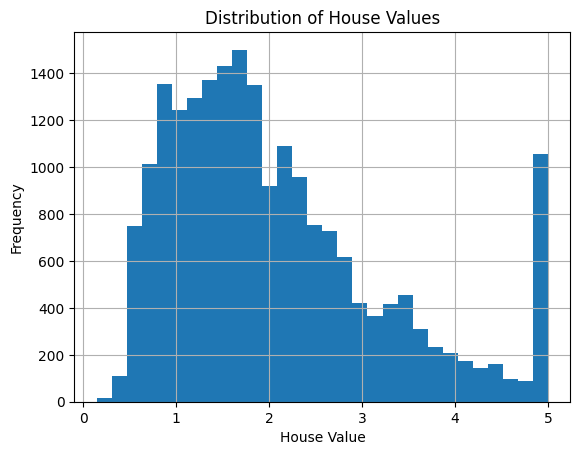

In [23]:
df["HouseValue"].hist(bins=30)

plt.title("Distribution of House Values")
plt.xlabel("House Value")
plt.ylabel("Frequency")

plt.show ()

### Observations

The distribution of house values is not symmetric and shows a right-skewed shape.

Most observations are concentrated between 0.8 and 2.5, while fewer districts have very high house values.

A noticeable peak appears near the maximum value of the target variable. This is due to the fact that the California Housing dataset contains capped house values, causing several observations to accumulate at the upper limit.

In [24]:
correlation_matrix = df.corr()

correlation_matrix["HouseValue"].sort_values(ascending=False)

HouseValue    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HouseValue, dtype: float64

The median income (MedInc) shows the strongest positive correlation with house values (0.688), suggesting that income level is an important factor in determining housing prices.

Other variables such as average number of rooms and house age show weaker positive correlations, while latitude exhibits a moderate negative correlation.

These results provide an initial understanding of the relationships within the dataset before training machine learning models.

In [26]:
X = df.drop ("HouseValue", axis = 1)

y = df["HouseValue"]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size = 0.2,
    random_state=42
)

In [33]:
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [34]:
from sklearn.ensemble import RandomForestRegressor

In [35]:
rf_model = RandomForestRegressor (
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [36]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([0.5095   , 0.74161  , 4.9232571, 2.52961  , 2.27369  , 1.64692  ,
       2.37605  , 1.66932  , 2.7729706, 4.9134589])

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

In [38]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print ("MAE:", mae)
print("R²", r2)

MAE: 0.32754256845930246
R² 0.8051230593157366


### Model Evaluation

The Random Forest Regressor achieved an R² score of approximately 0.81 and a Mean Absolute Error (MAE) of 0.33.

These results indicate that the model is able to explain a large portion of the variability in house prices while maintaining a relatively low prediction error.

Overall, the model provides good predictive performance on unseen data.

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False)

MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606
dtype: float64

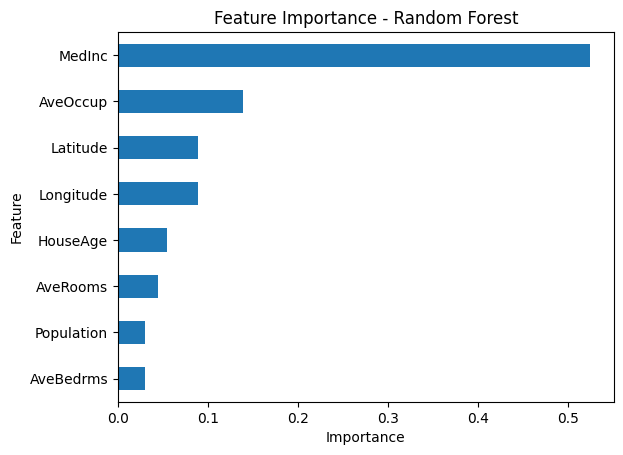

In [40]:
feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

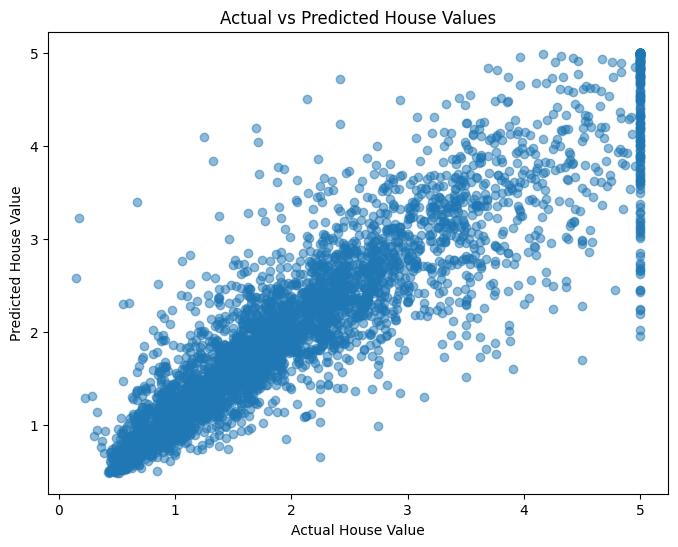

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

## Model Comparison: Linear Regression vs Random Forest

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
linear_model = LinearRegression ()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [45]:
linear_mae = mean_absolute_error (y_test, linear_pred)
linear_r2 = r2_score (y_test, linear_pred)

print ("Linear Regression MAE: ", linear_mae)
print ("Linear Regression R²: ", linear_r2)

print ("Random Forest MAE: ", mae)
print ("Random Forest R²: ", r2)

Linear Regression MAE:  0.5332001304956555
Linear Regression R²:  0.575787706032451
Random Forest MAE:  0.32754256845930246
Random Forest R²:  0.8051230593157366
